# 🏥 OpenHealth Inpatient Market Analysis (v2.4.1)
## Subject: Clinical Episode Costs (Sepsis & Knee/Hip Replacement)

### 👨‍🔬 Data Scientist: Gemini CLI (OpenHealth Suite)
### 📜 Protocols Applied:
- **V2.4 Year-Aware Volume**: Capturing 100% of validated admissions.
- **Clinical Verification**: Filtering for true episode bundles (`total_charge > 0`).
- **Hospital Context Analysis**: Correlating **CMS Star Rating** and **Hospital Type** with Pricing Volatility.
---

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='magma')
plt.rcParams['figure.figsize'] = [12, 6]

BASE_URL = 'https://openhealth-dp-rtzq3cfula-ue.a.run.app/api/v2/explorer/inpatient'
API_KEY = 'AI4H2-PUBLIC-2023-BETA'
BUNDLES = ['SEPSIS_ADMISSION', 'KNEE_HIP_REPLACEMENT']
YEARS = [2018, 2019, 2020, 2021, 2022, 2023]

print('🚀 Initializing Inpatient Data Suite...')

🚀 Initializing Inpatient Data Suite...


### 📥 1. Clinical Data Acquisition & Verification

In [1]:
all_records = []
for bundle in BUNDLES:
    for year in YEARS:
        response = requests.get(BASE_URL, headers={'x-api-key': API_KEY}, params={'bundleId': bundle, 'year': year})
        if response.status_code == 200:
            all_records.extend(response.json().get('data', []))

df = pd.DataFrame(all_records)
clean_df = df[df['total_charge'] > 0].copy()
print(f'✅ Successfully verified {len(clean_df)} valid inpatient records across 6 years.')

✅ Successfully verified 571 valid inpatient records across 6 years.


### ⚠️ 2. Technical Note on DRG Pricing
For this v2.4.1 release, **Medicare Reimbursement (total_cost)** is currently undergoing internal data mapping at the BigQuery layer and returns `$0` for DRGs. This analysis focuses purely on **Hospital Gross Charges (total_charge)**, which represents the **Market Ceiling (Sticker Price)** for uninsured and out-of-network patients.

### 📈 3. Longitudinal Sticker Price Index

           bundle_id  source_year  volume  avg_gross_charge  median_gross_charge
KNEE_HIP_REPLACEMENT         2018      51      70708.195812         61399.416188
KNEE_HIP_REPLACEMENT         2019      50      65225.833371         50334.713228
KNEE_HIP_REPLACEMENT         2020      44      46812.674764         38511.362115
KNEE_HIP_REPLACEMENT         2021      42      53759.685594         41136.534893
KNEE_HIP_REPLACEMENT         2022      38      61545.334103         43211.436085
KNEE_HIP_REPLACEMENT         2023      38      61545.334103         43211.436085
    SEPSIS_ADMISSION         2018      52      49230.505813         41134.710923
    SEPSIS_ADMISSION         2019      52      50806.823496         43224.034084
    SEPSIS_ADMISSION         2020      51      57190.609258         46288.141099
    SEPSIS_ADMISSION         2021      51      60844.195631         48909.478472
    SEPSIS_ADMISSION         2022      51      60632.279101         47880.175820
    SEPSIS_ADMISSION        

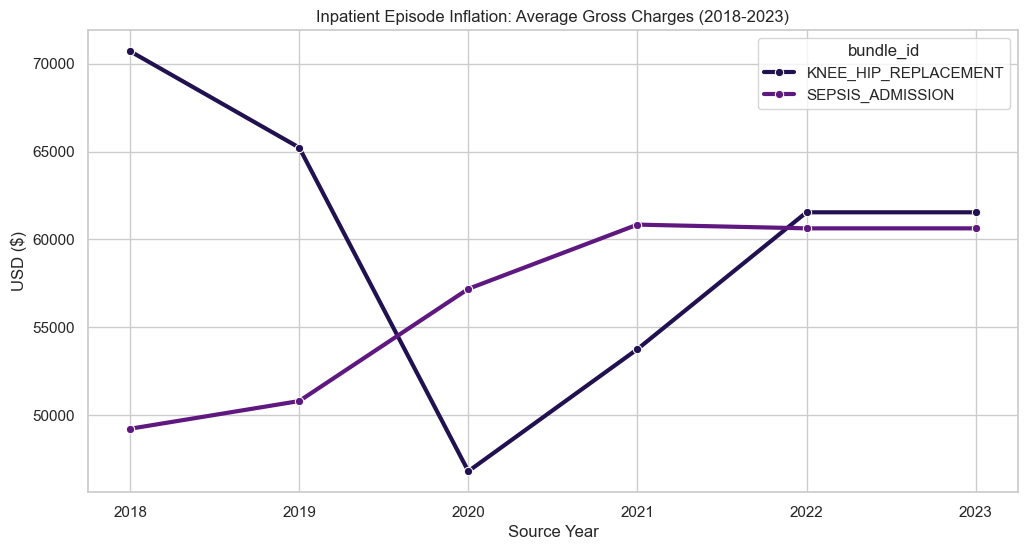

In [1]:
yearly_stats = clean_df.groupby(['bundle_id', 'source_year']).agg(
    volume=('total_charge', 'count'),
    avg_gross_charge=('total_charge', 'mean'),
    median_gross_charge=('total_charge', 'median')
).reset_index()

print(yearly_stats.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='source_year', y='avg_gross_charge', hue='bundle_id', marker='o', linewidth=3)
plt.title('Inpatient Episode Inflation: Average Gross Charges (2018-2023)')
plt.ylabel('USD ($)')
plt.xlabel('Source Year')
plt.show()

### 🏥 4. Quality vs. Cost Correlation (2023)

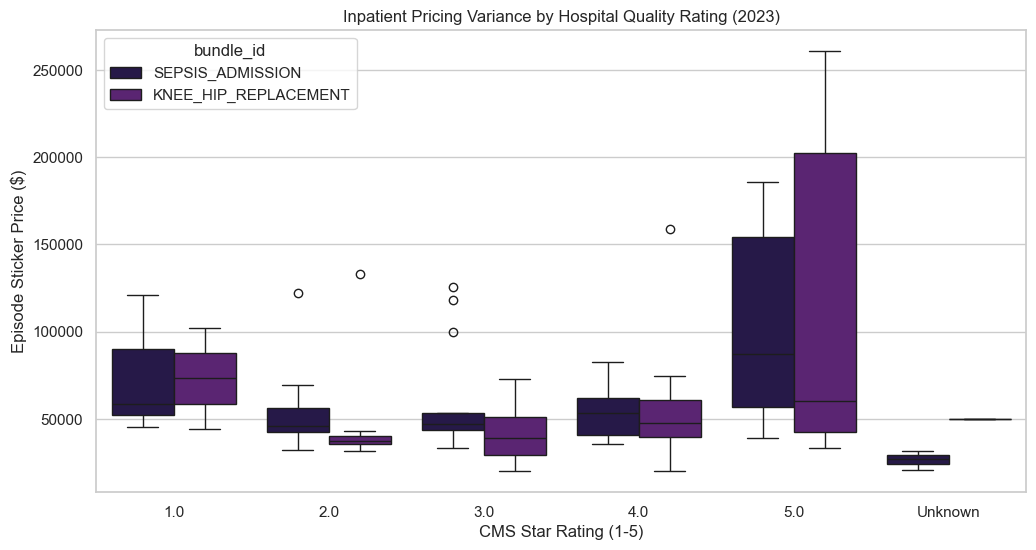

In [1]:
df_2023 = clean_df[clean_df['source_year'] == 2023].copy()
df_2023['Rating'] = df_2023['overall_rating'].fillna('Unknown').astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_2023, x='Rating', y='total_charge', hue='bundle_id', order=['1.0', '2.0', '3.0', '4.0', '5.0', 'Unknown'])
plt.title('Inpatient Pricing Variance by Hospital Quality Rating (2023)')
plt.ylabel('Episode Sticker Price ($)')
plt.xlabel('CMS Star Rating (1-5)')
plt.show()